
# Probability of Default Model

## Credit Risk Intelligence Lab

This notebook builds the first supervised learning model of the project: a baseline **Probability of Default (PD)** model.

The objective is not only to classify borrowers as good or bad credit risks. The objective is to estimate a risk score that can be interpreted as a probability of default and later used for portfolio analysis, segmentation, anomaly detection, explainability, and stress testing.

In credit risk, a baseline logistic regression model is especially useful because it is transparent, stable, interpretable, and historically aligned with scorecard-style modeling. More complex models may improve predictive performance, but the baseline model gives the project a strong analytical reference point.



## Notebook objectives

This notebook focuses on the following tasks:

1. Load the processed modeling datasets created in the feature engineering notebook.
2. Train a baseline logistic regression model for probability of default.
3. Evaluate model performance using classification and ranking metrics.
4. Analyze predicted default probabilities through score bands and risk deciles.
5. Estimate a simple expected loss proxy using PD, exposure, and an assumed LGD.
6. Inspect model coefficients for interpretability.
7. Save the trained baseline model and model outputs for later notebooks.

The natural next step after this notebook will be unsupervised borrower segmentation.


In [1]:

from pathlib import Path
import warnings
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Project paths

The notebook is designed to run either from the project root or from the `notebooks/` directory.


In [2]:

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"

for path in [DATA_PROCESSED, MODELS_DIR, REPORTS_FIGURES, REPORTS_TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data path: {DATA_PROCESSED}")
print(f"Models path: {MODELS_DIR}")
print(f"Figures path: {REPORTS_FIGURES}")


Project root: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab
Processed data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed
Models path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/models
Figures path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/figures



## Load processed modeling datasets

This notebook expects the second notebook to have generated the processed train-test files:

```text
data/processed/X_train_processed.csv
data/processed/X_test_processed.csv
data/processed/y_train.csv
data/processed/y_test.csv
```

It also loads the raw train-test splits because those files preserve interpretable variables such as `credit_amount`, which will be useful for portfolio-level risk analysis.


In [3]:

required_files = {
    "X_train_processed": DATA_PROCESSED / "X_train_processed.csv",
    "X_test_processed": DATA_PROCESSED / "X_test_processed.csv",
    "y_train": DATA_PROCESSED / "y_train.csv",
    "y_test": DATA_PROCESSED / "y_test.csv",
    "X_train_raw": DATA_PROCESSED / "X_train.csv",
    "X_test_raw": DATA_PROCESSED / "X_test.csv",
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing processed files: "
        + ", ".join(missing_files)
        + ". Run notebooks/02_feature_engineering.ipynb before this notebook."
    )

X_train = pd.read_csv(required_files["X_train_processed"], index_col=0)
X_test = pd.read_csv(required_files["X_test_processed"], index_col=0)

y_train = pd.read_csv(required_files["y_train"], index_col=0).iloc[:, 0]
y_test = pd.read_csv(required_files["y_test"], index_col=0).iloc[:, 0]

X_train_raw = pd.read_csv(required_files["X_train_raw"], index_col=0)
X_test_raw = pd.read_csv(required_files["X_test_raw"], index_col=0)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (800, 79)
X_test: (200, 79)
y_train: (800,)
y_test: (200,)


In [4]:

X_train.head()


,duration_months,credit_amount,installment_rate_pct_income,present_residence_since,age_years,existing_credits,people_liable,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,checking_account_status_A11,checking_account_status_A12,checking_account_status_A13,checking_account_status_A14,credit_history_A30,credit_history_A31,credit_history_A32,credit_history_A33,credit_history_A34,purpose_A40,purpose_A41,purpose_A410,purpose_A42,purpose_A43,purpose_A44,purpose_A45,purpose_A46,purpose_A48,purpose_A49,savings_account_A61,savings_account_A62,savings_account_A63,savings_account_A64,savings_account_A65,employment_since_A71,employment_since_A72,employment_since_A73,employment_since_A74,employment_since_A75,personal_status_sex_A91,personal_status_sex_A92,personal_status_sex_A93,personal_status_sex_A94,other_debtors_guarantors_A101,other_debtors_guarantors_A102,other_debtors_guarantors_A103,property_A121,property_A122,property_A123,property_A124,other_installment_plans_A141,other_installment_plans_A142,other_installment_plans_A143,housing_A151,housing_A152,housing_A153,job_A171,job_A172,job_A173,job_A174,telephone_A191,telephone_A192,foreign_worker_A201,foreign_worker_A202,age_bucket_early_career,age_bucket_mid_career,age_bucket_senior,age_bucket_young,duration_bucket_long_term,duration_bucket_medium_term,duration_bucket_short_term,duration_bucket_very_long_term,credit_amount_bucket_high_amount,credit_amount_bucket_low_amount,credit_amount_bucket_medium_high_amount,credit_amount_bucket_medium_low_amount
828,1.2896,1.9258,0.0523,1.0534,1.0578,-0.7187,-0.4364,0.5928,1.6322,1.2896,2.2194,1.7614,2.0515,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
997,-0.7426,-0.8929,0.9422,1.0534,0.2424,-0.7187,-0.4364,-0.8210,-1.4040,-0.7426,-0.4506,-0.5677,-0.6830,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000
148,1.2896,0.8164,0.0523,-0.7473,-0.6635,1.0450,-0.4364,-0.1147,1.0614,1.2896,2.2194,1.7614,0.9356,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
735,1.2896,0.2996,0.0523,-0.7473,-0.5729,-0.7187,-0.4364,-0.4443,0.6755,1.2896,2.2194,1.7614,0.4156,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
130,2.3057,1.9827,-1.7275,-0.7473,-1.0258,-0.7187,-0.4364,0.1226,1.6556,2.3057,2.2194,1.7614,-0.0215,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0


## Target distribution in train and test

Before modeling, we verify that the train-test split preserves the default rate.


In [5]:

target_split_summary = pd.DataFrame(
    {
        "sample": ["train", "test"],
        "observations": [len(y_train), len(y_test)],
        "default_rate": [y_train.mean(), y_test.mean()],
        "non_default_rate": [1 - y_train.mean(), 1 - y_test.mean()],
    }
)

target_split_summary


,sample,observations,default_rate,non_default_rate
0,train,800,0.3000,0.7000
1,test,200,0.3000,0.7000



## Baseline logistic regression model

Logistic regression is a strong first model for credit risk because its output is naturally probabilistic and its coefficients can be interpreted directionally.

The model uses `class_weight="balanced"` because credit risk datasets often contain fewer default observations than non-default observations. This does not automatically make the model better, but it helps the baseline pay more attention to the minority class.


In [6]:

baseline_pd_model = LogisticRegression(
    max_iter=2_000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42,
)

baseline_pd_model.fit(X_train, y_train)

print("Baseline PD model trained.")


Baseline PD model trained.



## Predict default probabilities

The model produces a probability of default for each borrower.

```text
PD = P(default = 1)
```

For classification metrics, we initially use a threshold of 0.50. However, in credit risk, the probability ranking and score bands are often more informative than a single hard threshold.


In [7]:

train_pd = baseline_pd_model.predict_proba(X_train)[:, 1]
test_pd = baseline_pd_model.predict_proba(X_test)[:, 1]

threshold = 0.50

train_pred = (train_pd >= threshold).astype(int)
test_pred = (test_pd >= threshold).astype(int)

pd.DataFrame(
    {
        "actual_default": y_test,
        "predicted_pd": test_pd,
        "predicted_class_0_50": test_pred,
    }
).head()


,actual_default,predicted_pd,predicted_class_0_50
30,0,0.3672,0
128,0,0.1117,0
289,1,0.8476,1
216,0,0.6924,1
966,1,0.2095,0



## Classification and ranking metrics

A credit risk model should not be evaluated only by accuracy. Accuracy can be misleading when the default class is less frequent.

This notebook reports:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision
- Brier Score
- Gini coefficient

The Gini coefficient is calculated from ROC-AUC:

```text
Gini = 2 × ROC-AUC − 1
```


In [8]:

def evaluate_binary_model(y_true, y_pred, y_score, sample_name: str) -> dict:
    roc_auc = roc_auc_score(y_true, y_score)
    metrics = {
        "sample": sample_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "gini": 2 * roc_auc - 1,
        "average_precision": average_precision_score(y_true, y_score),
        "brier_score": brier_score_loss(y_true, y_score),
    }
    return metrics

metrics_df = pd.DataFrame(
    [
        evaluate_binary_model(y_train, train_pred, train_pd, "train"),
        evaluate_binary_model(y_test, test_pred, test_pd, "test"),
    ]
)

metrics_df


,sample,accuracy,precision,recall,f1_score,roc_auc,gini,average_precision,brier_score
0,train,0.7562,0.5676,0.7875,0.6597,0.8482,0.6964,0.6993,0.1610
1,test,0.7200,0.5250,0.7000,0.6000,0.7965,0.5931,0.6674,0.1867


In [9]:

print("Classification report - test sample")
print(classification_report(y_test, test_pred, target_names=["good_credit", "bad_credit"]))


Classification report - test sample
              precision    recall  f1-score   support

 good_credit       0.85      0.73      0.78       140
  bad_credit       0.53      0.70      0.60        60

    accuracy                           0.72       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.75      0.72      0.73       200




## Confusion matrix

The confusion matrix shows the number of true positives, false positives, true negatives, and false negatives at the selected threshold.

In credit risk, the choice of threshold is a business decision. A lower threshold may identify more risky borrowers, but it may also reject or flag more good borrowers.


In [10]:

cm = confusion_matrix(y_test, test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual good_credit", "Actual bad_credit"],
    columns=["Predicted good_credit", "Predicted bad_credit"],
)

cm_df


,Predicted good_credit,Predicted bad_credit
Actual good_credit,102,38
Actual bad_credit,18,42


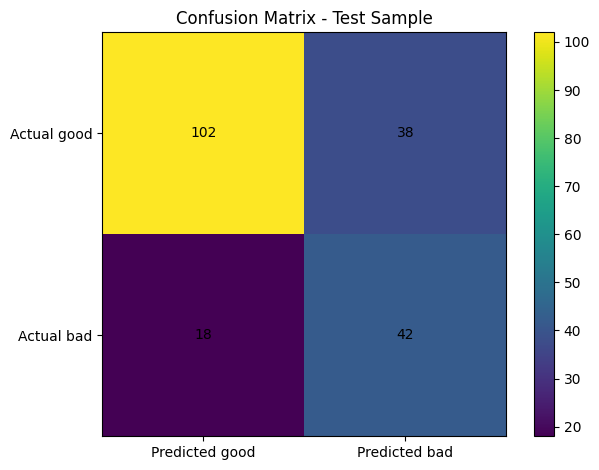

In [11]:

fig, ax = plt.subplots()

im = ax.imshow(cm)

ax.set_title("Confusion Matrix - Test Sample")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted good", "Predicted bad"])
ax.set_yticklabels(["Actual good", "Actual bad"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_confusion_matrix.png", dpi=150)
plt.show();



## ROC curve

The ROC curve evaluates the model's ability to rank risky borrowers above safer borrowers across different thresholds.

A random model would have an ROC-AUC close to 0.50. A stronger model moves the curve closer to the upper-left corner.


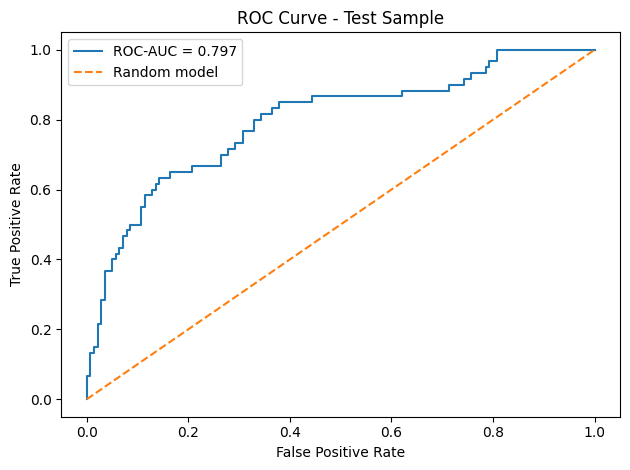

In [12]:

fpr, tpr, roc_thresholds = roc_curve(y_test, test_pd)
test_roc_auc = roc_auc_score(y_test, test_pd)

fig, ax = plt.subplots()

ax.plot(fpr, tpr, label=f"ROC-AUC = {test_roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random model")

ax.set_title("ROC Curve - Test Sample")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_roc_curve.png", dpi=150)
plt.show();



## Precision-recall curve

The precision-recall curve is useful when the positive class is relatively less frequent.

In this project, the positive class is `default = 1`.


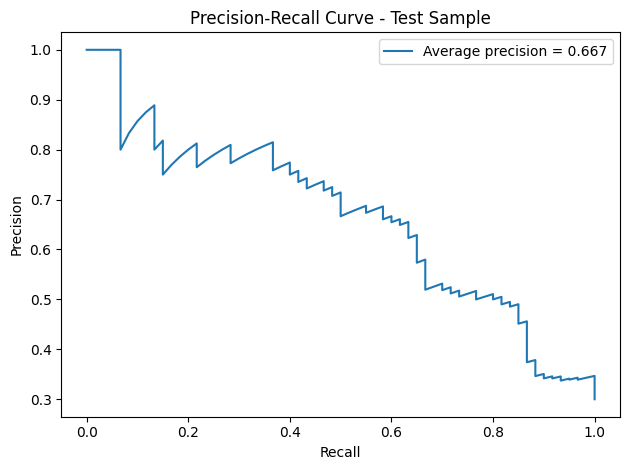

In [13]:

precision, recall, pr_thresholds = precision_recall_curve(y_test, test_pd)
avg_precision = average_precision_score(y_test, test_pd)

fig, ax = plt.subplots()

ax.plot(recall, precision, label=f"Average precision = {avg_precision:.3f}")

ax.set_title("Precision-Recall Curve - Test Sample")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_precision_recall_curve.png", dpi=150)
plt.show();



## KS statistic

The Kolmogorov-Smirnov statistic is common in credit scoring. It measures the maximum separation between the cumulative distribution of scores for default and non-default borrowers.

A higher KS indicates stronger separation between good and bad credit risks.


In [14]:

def ks_statistic(y_true, y_score) -> tuple:
    data = pd.DataFrame({"y_true": y_true, "score": y_score})
    data = data.sort_values("score", ascending=False).reset_index(drop=True)

    total_defaults = data["y_true"].sum()
    total_non_defaults = len(data) - total_defaults

    data["cum_defaults"] = data["y_true"].cumsum() / total_defaults
    data["cum_non_defaults"] = (1 - data["y_true"]).cumsum() / total_non_defaults
    data["ks"] = np.abs(data["cum_defaults"] - data["cum_non_defaults"])

    ks_value = data["ks"].max()
    ks_position = data["ks"].idxmax()

    return ks_value, ks_position, data

ks_value, ks_position, ks_table = ks_statistic(y_test, test_pd)

print(f"KS statistic: {ks_value:.4f}")
print(f"KS position: {ks_position}")


KS statistic: 0.4905
KS position: 57


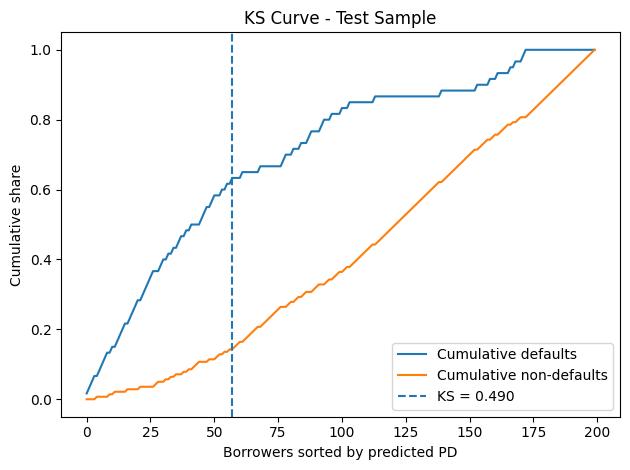

In [15]:

fig, ax = plt.subplots()

ax.plot(ks_table.index, ks_table["cum_defaults"], label="Cumulative defaults")
ax.plot(ks_table.index, ks_table["cum_non_defaults"], label="Cumulative non-defaults")
ax.axvline(ks_position, linestyle="--", label=f"KS = {ks_value:.3f}")

ax.set_title("KS Curve - Test Sample")
ax.set_xlabel("Borrowers sorted by predicted PD")
ax.set_ylabel("Cumulative share")
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_ks_curve.png", dpi=150)
plt.show();



## Probability distribution

This section compares the distribution of predicted PD between actual good and bad credit borrowers.

A useful PD model should assign, on average, higher probabilities to borrowers who actually defaulted.


In [16]:

test_results = pd.DataFrame(
    {
        "actual_default": y_test,
        "predicted_pd": test_pd,
    },
    index=y_test.index,
)

test_results.groupby("actual_default")["predicted_pd"].describe()


,count,mean,std,min,25%,50%,75%,max
actual_default,,,,,,,,
0,140.0000,0.3480,0.2563,0.0088,0.1392,0.3095,0.5380,0.9567
1,60.0000,0.6635,0.2751,0.0842,0.4754,0.7579,0.8839,0.9985


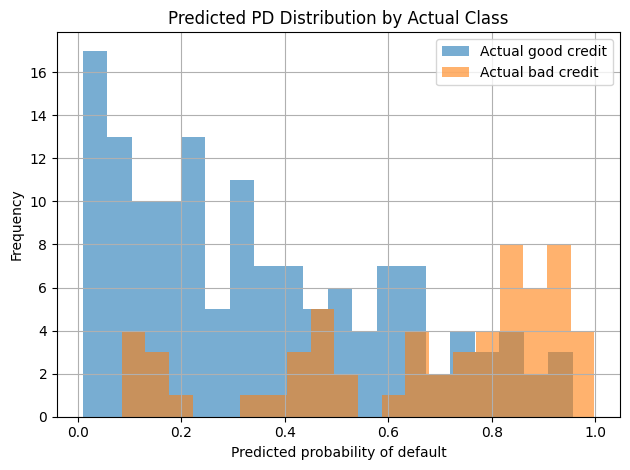

In [17]:

fig, ax = plt.subplots()

test_results.loc[test_results["actual_default"] == 0, "predicted_pd"].hist(
    bins=20,
    alpha=0.6,
    ax=ax,
    label="Actual good credit",
)

test_results.loc[test_results["actual_default"] == 1, "predicted_pd"].hist(
    bins=20,
    alpha=0.6,
    ax=ax,
    label="Actual bad credit",
)

ax.set_title("Predicted PD Distribution by Actual Class")
ax.set_xlabel("Predicted probability of default")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_pd_distribution.png", dpi=150)
plt.show();



## Risk deciles

Credit risk models are often used as ranking systems. Instead of focusing only on a 0.50 classification threshold, we can divide borrowers into deciles based on predicted PD.

The highest decile should concentrate more defaults than the lowest decile if the model is useful.


In [18]:

test_results["pd_decile"] = pd.qcut(
    test_results["predicted_pd"],
    q=10,
    labels=False,
    duplicates="drop",
)

# Reverse scale so that decile 1 is the highest-risk group.
max_decile = test_results["pd_decile"].max()
test_results["risk_decile"] = max_decile - test_results["pd_decile"] + 1

decile_summary = (
    test_results
    .groupby("risk_decile")
    .agg(
        borrowers=("actual_default", "size"),
        defaults=("actual_default", "sum"),
        observed_default_rate=("actual_default", "mean"),
        min_pd=("predicted_pd", "min"),
        avg_pd=("predicted_pd", "mean"),
        max_pd=("predicted_pd", "max"),
    )
    .sort_index()
)

decile_summary


,borrowers,defaults,observed_default_rate,min_pd,avg_pd,max_pd
risk_decile,,,,,,
1,20,16,0.8000,0.8819,0.9311,0.9985
2,20,13,0.6500,0.7744,0.8289,0.8707
3,20,9,0.4500,0.6447,0.7103,0.7730
4,20,4,0.2000,0.5054,0.5793,0.6427
5,20,7,0.3500,0.4222,0.4605,0.4975
6,20,3,0.1500,0.3247,0.3610,0.4211
7,20,1,0.0500,0.2095,0.2505,0.3121
8,20,2,0.1000,0.1413,0.1692,0.2084
9,20,5,0.2500,0.0718,0.0959,0.1331


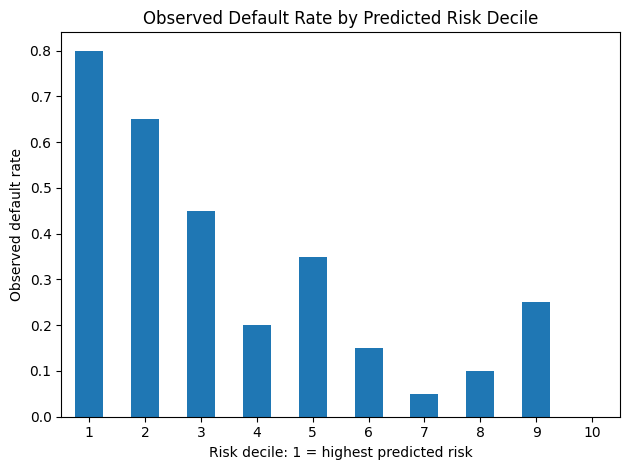

In [19]:

fig, ax = plt.subplots()

decile_summary["observed_default_rate"].plot(kind="bar", ax=ax)

ax.set_title("Observed Default Rate by Predicted Risk Decile")
ax.set_xlabel("Risk decile: 1 = highest predicted risk")
ax.set_ylabel("Observed default rate")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_default_rate_by_decile.png", dpi=150)
plt.show();



## Risk bands

Risk bands are more interpretable than raw probabilities. They can be used in a dashboard, report, or underwriting policy simulation.

The thresholds below are illustrative and should not be interpreted as final credit policy.


In [20]:

def assign_risk_band(pd_value: float) -> str:
    if pd_value < 0.20:
        return "low_risk"
    elif pd_value < 0.40:
        return "moderate_risk"
    elif pd_value < 0.60:
        return "elevated_risk"
    else:
        return "high_risk"

test_results["risk_band"] = test_results["predicted_pd"].apply(assign_risk_band)

risk_band_summary = (
    test_results
    .groupby("risk_band")
    .agg(
        borrowers=("actual_default", "size"),
        defaults=("actual_default", "sum"),
        observed_default_rate=("actual_default", "mean"),
        average_pd=("predicted_pd", "mean"),
    )
    .assign(portfolio_share=lambda x: x["borrowers"] / len(test_results))
    .sort_values("average_pd", ascending=False)
)

risk_band_summary


,borrowers,defaults,observed_default_rate,average_pd,portfolio_share
risk_band,,,,,
high_risk,68,39,0.5735,0.8000,0.3400
elevated_risk,35,11,0.3143,0.4873,0.1750
moderate_risk,40,3,0.0750,0.2897,0.2000
low_risk,57,7,0.1228,0.0963,0.2850



## Expected loss proxy

A basic credit risk framework defines expected loss as:

```text
Expected Loss = PD × LGD × EAD
```

Where:

- **PD** is probability of default.
- **LGD** is loss given default.
- **EAD** is exposure at default.

The German Credit dataset does not provide true LGD or EAD. For this notebook, we use:

- `credit_amount` as a simple exposure proxy.
- A constant assumed LGD of 45%.

This is not a regulatory expected loss model. It is a portfolio analytics approximation used to connect the probability model with credit risk management logic.


In [21]:

LGD_ASSUMPTION = 0.45

portfolio_results = test_results.join(
    X_test_raw[["credit_amount"]],
    how="left",
)

portfolio_results["ead_proxy"] = portfolio_results["credit_amount"]
portfolio_results["lgd_assumption"] = LGD_ASSUMPTION
portfolio_results["expected_loss_proxy"] = (
    portfolio_results["predicted_pd"]
    * portfolio_results["lgd_assumption"]
    * portfolio_results["ead_proxy"]
)

portfolio_results.head()


,actual_default,predicted_pd,pd_decile,risk_decile,risk_band,credit_amount,ead_proxy,lgd_assumption,expected_loss_proxy
30,0,0.3672,4,6,moderate_risk,1913,1913,0.4500,316.1313
128,0,0.1117,1,9,low_risk,1860,1860,0.4500,93.4931
289,1,0.8476,8,2,high_risk,1024,1024,0.4500,390.5526
216,0,0.6924,7,3,high_risk,3104,3104,0.4500,967.1048
966,1,0.2095,3,7,moderate_risk,2520,2520,0.4500,237.5229


In [22]:

portfolio_expected_loss_summary = {
    "test_portfolio_exposure_proxy": portfolio_results["ead_proxy"].sum(),
    "average_predicted_pd": portfolio_results["predicted_pd"].mean(),
    "lgd_assumption": LGD_ASSUMPTION,
    "total_expected_loss_proxy": portfolio_results["expected_loss_proxy"].sum(),
    "expected_loss_rate_proxy": portfolio_results["expected_loss_proxy"].sum() / portfolio_results["ead_proxy"].sum(),
}

portfolio_expected_loss_summary


{'test_portfolio_exposure_proxy': np.int64(719585),
 'average_predicted_pd': np.float64(0.4426687255818196),
 'lgd_assumption': 0.45,
 'total_expected_loss_proxy': np.float64(171673.21376069885),
 'expected_loss_rate_proxy': np.float64(0.23857252966737613)}

In [23]:

expected_loss_by_band = (
    portfolio_results
    .groupby("risk_band")
    .agg(
        borrowers=("actual_default", "size"),
        exposure_proxy=("ead_proxy", "sum"),
        avg_pd=("predicted_pd", "mean"),
        expected_loss_proxy=("expected_loss_proxy", "sum"),
        observed_default_rate=("actual_default", "mean"),
    )
    .assign(
        exposure_share=lambda x: x["exposure_proxy"] / x["exposure_proxy"].sum(),
        expected_loss_share=lambda x: x["expected_loss_proxy"] / x["expected_loss_proxy"].sum(),
    )
    .sort_values("avg_pd", ascending=False)
)

expected_loss_by_band


,borrowers,exposure_proxy,avg_pd,expected_loss_proxy,observed_default_rate,exposure_share,expected_loss_share
risk_band,,,,,,,
high_risk,68,325153,0.8000,"120,453.5660",0.5735,0.4519,0.7016
elevated_risk,35,125512,0.4873,"27,997.1973",0.3143,0.1744,0.1631
moderate_risk,40,130857,0.2897,"17,284.5125",0.0750,0.1819,0.1007
low_risk,57,138063,0.0963,"5,937.9380",0.1228,0.1919,0.0346



## Model coefficient interpretation

For logistic regression, coefficients indicate the direction of association between a feature and the log-odds of default.

Positive coefficients are associated with higher estimated default risk. Negative coefficients are associated with lower estimated default risk.

Because the model uses one-hot encoded variables and scaled numerical variables, coefficients should be interpreted as directional model signals, not as direct causal effects.


In [24]:

coefficients = pd.DataFrame(
    {
        "feature": X_train.columns,
        "coefficient": baseline_pd_model.coef_[0],
    }
)

coefficients["absolute_coefficient"] = coefficients["coefficient"].abs()

top_positive_coefficients = (
    coefficients
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_negative_coefficients = (
    coefficients
    .sort_values("coefficient", ascending=True)
    .head(15)
)

top_positive_coefficients


,feature,coefficient,absolute_coefficient
29,purpose_A46,0.9821,0.9821
76,credit_amount_bucket_low_amount,0.7693,0.7693
13,checking_account_status_A11,0.6982,0.6982
17,credit_history_A30,0.6933,0.6933
65,foreign_worker_A201,0.6505,0.6505
52,property_A124,0.6242,0.6242
32,savings_account_A61,0.5766,0.5766
42,personal_status_sex_A91,0.5259,0.5259
53,other_installment_plans_A141,0.5252,0.5252
28,purpose_A45,0.5024,0.5024


In [25]:
top_negative_coefficients

,feature,coefficient,absolute_coefficient
16,checking_account_status_A14,-0.9918,0.9918
23,purpose_A41,-0.9192,0.9192
21,credit_history_A34,-0.8767,0.8767
77,credit_amount_bucket_medium_high_amount,-0.7490,0.7490
66,foreign_worker_A202,-0.6666,0.6666
35,savings_account_A64,-0.6218,0.6218
74,duration_bucket_very_long_term,-0.6103,0.6103
40,employment_since_A74,-0.5569,0.5569
24,purpose_A410,-0.5272,0.5272
58,housing_A153,-0.4966,0.4966


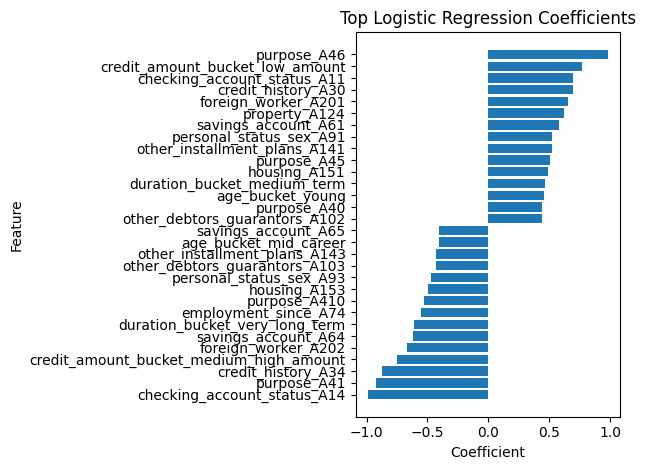

In [26]:

top_coefficients = pd.concat(
    [
        top_positive_coefficients.assign(direction="higher_risk"),
        top_negative_coefficients.assign(direction="lower_risk"),
    ],
    axis=0,
)

fig, ax = plt.subplots()

plot_data = top_coefficients.sort_values("coefficient")
ax.barh(plot_data["feature"], plot_data["coefficient"])

ax.set_title("Top Logistic Regression Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_logistic_regression_coefficients.png", dpi=150)
plt.show();



## Save model artifacts and outputs

This section saves the baseline model, predictions, metrics, and summary tables.

These outputs will be useful for later notebooks, the README, and a possible Streamlit dashboard.


In [27]:

model_path = MODELS_DIR / "baseline_logistic_pd_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(baseline_pd_model, f)

test_predictions_path = DATA_PROCESSED / "test_pd_predictions.csv"
portfolio_results.to_csv(test_predictions_path, index=True)

metrics_path = REPORTS_TABLES / "03_model_metrics.csv"
decile_path = REPORTS_TABLES / "03_risk_deciles.csv"
risk_band_path = REPORTS_TABLES / "03_risk_bands.csv"
coefficients_path = REPORTS_TABLES / "03_model_coefficients.csv"

metrics_df.to_csv(metrics_path, index=False)
decile_summary.to_csv(decile_path, index=True)
risk_band_summary.to_csv(risk_band_path, index=True)
coefficients.to_csv(coefficients_path, index=False)

model_metadata = {
    "model_name": "baseline_logistic_pd_model",
    "model_type": "LogisticRegression",
    "threshold": threshold,
    "random_state": 42,
    "class_weight": "balanced",
    "test_roc_auc": float(metrics_df.loc[metrics_df["sample"] == "test", "roc_auc"].iloc[0]),
    "test_gini": float(metrics_df.loc[metrics_df["sample"] == "test", "gini"].iloc[0]),
    "test_brier_score": float(metrics_df.loc[metrics_df["sample"] == "test", "brier_score"].iloc[0]),
    "lgd_assumption": LGD_ASSUMPTION,
}

with open(MODELS_DIR / "baseline_logistic_pd_model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print(f"Saved model to: {model_path}")
print(f"Saved predictions to: {test_predictions_path}")


Saved model to: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/models/baseline_logistic_pd_model.pkl
Saved predictions to: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed/test_pd_predictions.csv



## Analytical conclusions

This notebook created the first supervised probability of default model for the project.

The most important outputs are:

- A baseline logistic regression PD model.
- Classification and ranking metrics.
- ROC, precision-recall, KS, PD distribution, decile, and coefficient visualizations.
- Risk bands based on predicted probability of default.
- A simple expected loss proxy using PD, exposure proxy, and assumed LGD.
- Saved model artifacts for future use.

The model should not yet be interpreted as a final production-grade credit decision model. It is a baseline analytical model that establishes a clear benchmark.

The next notebook should focus on unsupervised learning:

```text
notebooks/04_unsupervised_risk_segmentation.ipynb
```

That stage will use the processed borrower features to discover hidden risk segments and compare those segments against the supervised PD model.
